# Explicabilidad

Como vimos durante los ejercicios con distintos modelos de datos, algunos de ellos muestran una estructura interpretable donde podemos entender la base sobre la que ciertas decisiones han sido tomadas. 

En otros casos, esta comprensión no es tan sencilla, de forma que los modelos que no facilitan tanto la interpretabilidad son consideradas **cajas negras**. Dentro de esta categorización los modelos basados en árboles de decision son los llamados **cajas blancas** aunque el empleo de técnicas de ensembling puede hacer que se reduzca significativamente nuestra capacidad de comprensión.

## Relevancia

Nuestros modelos se fijarán en distinta características del conjunto de datos, pero ¿en cuales? Es una pregunta muy relevante y existen multitud de casos donde no habernos hecho esta pregunta a supuesto un problema.

Tenemos casos donde el impacto de un modelo no auditado a tenido impactos penales: https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing

Casos donde el impacto puede aumentar sesgos existentes en la sociedad

![sesgos](img/sesgo.png)

O casos donde podemos exponer a riesgos a los usuarios de nuestras aplicaciones o que sean sujetos de malas prácticas.

* https://ieeexplore.ieee.org/document/8601309
* https://arxiv.org/abs/1712.09665


## Interpretar

Esencialmente lo que queremos entender ante una decisión tomada por un modelo es en base a qué criterios ha sido esa decisión tomada. Ya que aunque estadísticamente tenga sentido, podría resultar que debido a sesgos de los datos nuestra decisión no sea justa o ética.

### Frameworks

Algunos frameworks populares en este dominio son:

* Shap (https://shap.readthedocs.io/en/latest/index.html)
* InterpretML (https://interpret.ml/)
* Fairlearn (https://fairlearn.org/)

#### Valores Shapley

Los valores Shapley (SHAP) se basan en la teoría de juegos, específicamente en el concepto de valores de Shapley, desarrollado por Lloyd S. Shapley en 1953. Esta teoría se utiliza para asignar un valor de importancia a cada característica (o “jugador”) en un modelo, midiendo su contribución a la predicción global.

![shap](https://christophm.github.io/interpretable-ml-book/images/shapley-instance-intervention.jpg)

**Coaliciones y agregación**
SHAP crea coaliciones de características (conjuntos de jugadores sin repetición) y calcula la contribución de cada característica a la predicción mediante la agregación de valores Shapley. Esto permite evaluar la influencia individual de cada característica en la predicción, considerando su interacción con otras características.

**Linealidad y aditividad**
Los valores SHAP se representan como un método de atribución de características aditiva y lineal. Esto significa que la contribución de cada característica se puede sumar para obtener la contribución total a la predicción. Esta propiedad lineal y aditiva facilita la interpretación de los resultados y la visualización de las explicaciones.

**Unidad atómica**
Los valores SHAP se consideran la “unidad atómica” de las interpretaciones globales. Esto significa que los valores SHAP son la base para las explicaciones locales y globales, permitiendo una comprensión coherente y objetiva de cómo cada característica influye en la predicción.

**Transferible a modelos no lineales**
Aunque la teoría de juegos se basa en suposiciones lineales, los valores SHAP se pueden aplicar a modelos no lineales, como modelos de árboles o redes neuronales, mediante aproximaciones y optimizaciones. Esto permite extender la explicabilidad a un amplio rango de modelos de machine learning.

Probemos qué pinta tienen de forma práctica. Tenéis mucho más detalle en la siguiente página: https://christophm.github.io/interpretable-ml-book

In [2]:
# !pip install shap

In [ ]:
import shap
import sklearn

# información de la vivienda en california
X, y = shap.datasets.california(n_points=1000)

# 100 muestras aleatorias sobre la distribución original
X100 = shap.utils.sample(X, 100)

# Un simple modelo lineal
model = sklearn.linear_model.LinearRegression()
model.fit(X, y)

In [4]:
print("Model coefficients:\n")
for i in range(X.shape[1]):
    print(X.columns[i], "=", model.coef_[i].round(5))

Model coefficients:

MedInc = 0.42563
HouseAge = 0.01033
AveRooms = -0.1161
AveBedrms = 0.66385
Population = 3e-05
AveOccup = -0.26096
Latitude = -0.46734
Longitude = -0.46272


Aunque los coeficientes son excelentes para saber qué ocurrirá cuando cambiemos el valor de una característica de entrada, por sí solos no son una buena forma de medir la importancia global de una característica.

Esto se debe a que el valor de cada coeficiente depende de la escala de las características de entrada. Si, por ejemplo, midiéramos la antigüedad de una casa en minutos en lugar de en años, los coeficientes de la característica HouseAge serían 0,0115 / (365∗24∗60) = 2,18e-8.

Es evidente que el número de años transcurridos desde que se construyó una casa no es más importante que el número de minutos, y sin embargo su valor de coeficiente es mucho mayor. Esto significa que la magnitud de un coeficiente no es necesariamente una buena medida de la importancia de una característica en un modelo lineal. Esta es una de las razones por las que el escalado de los datos es un factor importante a la hora de interpretar la relevancia basado en los coeficientes asignados.

Para entender la importancia de una característica en un modelo, es necesario comprender cómo afecta el cambio de esa característica a los resultados del modelo y también la distribución de los valores de esa característica. Para visualizar esto en un modelo lineal, podemos construir un gráfico de dependencia parcial clásico y mostrar la distribución de los valores de las características como un histograma en el eje x:

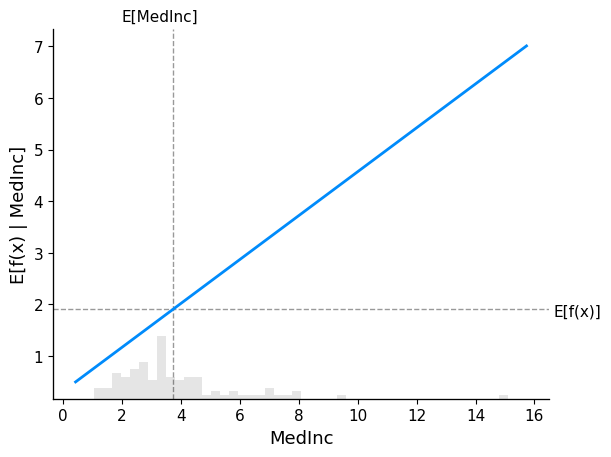

In [3]:
shap.partial_dependence_plot(
    "MedInc",
    model.predict,
    X100,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

La línea horizontal gris del gráfico anterior representa el valor esperado del modelo cuando se aplica al conjunto de datos de vivienda de California. La línea vertical gris representa el valor medio de la mediana de ingresos. 

Observad que la línea azul del gráfico de dependencia parcial (que es el valor medio de la salida del modelo cuando fijamos la característica de renta mediana en un valor determinado) siempre pasa por la intersección de las dos líneas grises de valor esperado. Podemos considerar este punto de intersección como el **centro** del gráfico de dependencia parcial con respecto a la distribución de los datos.

El impacto de este centrado quedará claro cuando pasemos a los valores de Shapley a continuación.

En la raíz de los valores Shapley reside en el valor condicional de la predicción dado un subconjunto del dataset original:

$$

E\left[ f(x) | X_s = x_s\right]

$$

Los valores SHAP pueden ser muy complicados de calcular (en general, son NP-hard), pero los modelos lineales son tan sencillos que podemos leer los valores SHAP directamente en un gráfico de dependencia parcial. Cuando explicamos una predicción  $f(X)$, el valor SHAP de una característica concreta 
 no es más que la diferencia entre el resultado esperado del modelo y el gráfico de dependencia parcial en el valor de la característica:

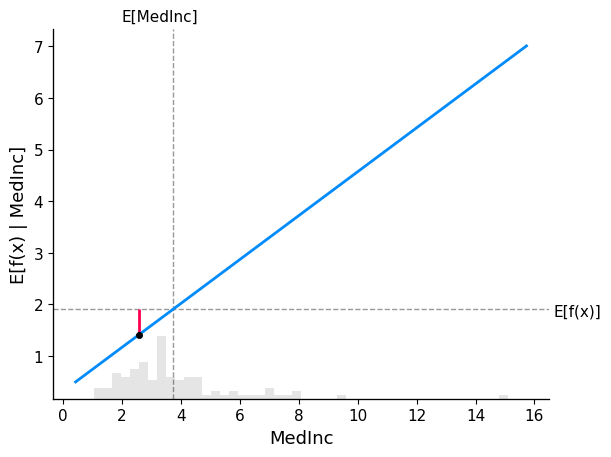

In [5]:
# compute the SHAP values for the linear model
explainer = shap.Explainer(model.predict, X100)
shap_values = explainer(X)

# make a standard partial dependence plot
sample_ind = 20
shap.partial_dependence_plot(
    "MedInc",
    model.predict,
    X100,
    model_expected_value=True,
    feature_expected_value=True,
    ice=False,
    shap_values=shap_values[sample_ind : sample_ind + 1, :],
)

Realizando esta operación para cada característica podemos obtener un gráfico de cascada sobre la relevancia de cada variable. Dado el valor esperado de la variable objetivo $E\left[ f(X)\right]$ podemos observar la contribución de las distintas variables a la obtención del valor $f(x)$.

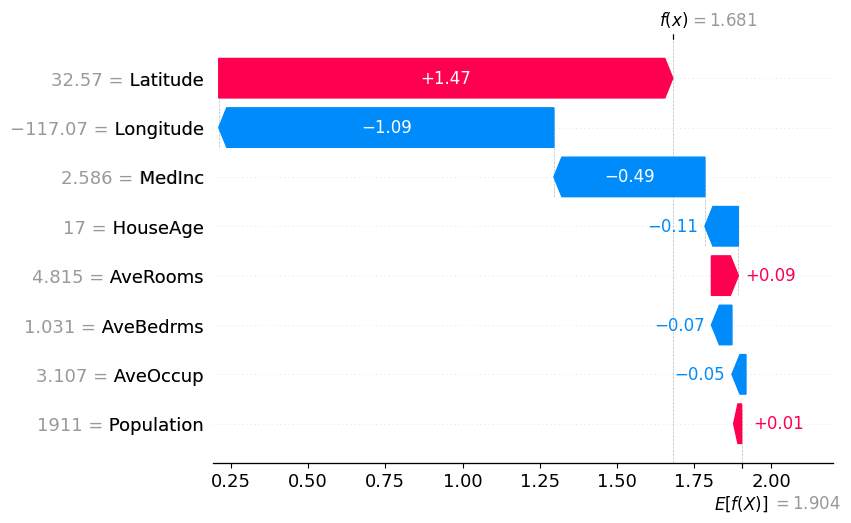

In [ ]:
# el waterfall_plot muestra como se llega desde shap_values.base_values al model.predict(X)[sample_ind]
shap.plots.waterfall(shap_values[sample_ind], max_display=14)

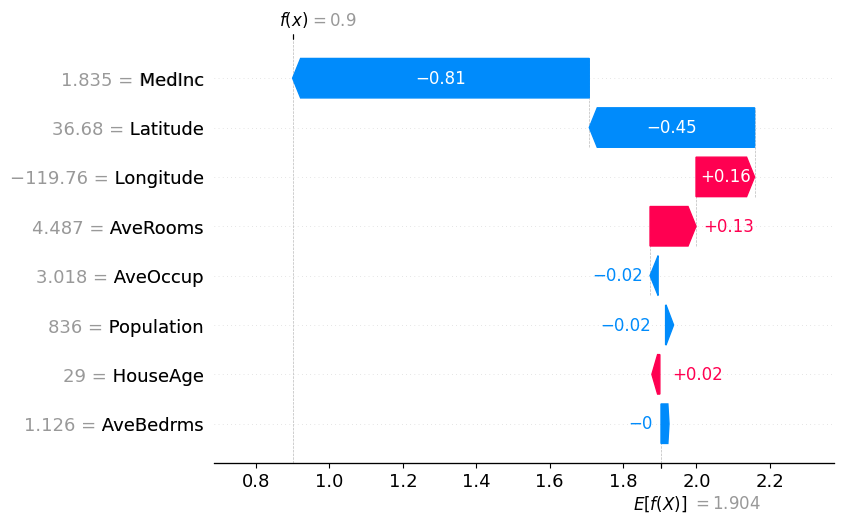

In [7]:
shap.plots.waterfall(shap_values[sample_ind+1], max_display=14)

### InterpretML

Entre los modelos explicativos que nos ofrecen librerías como [InterpretML](https://interpret.ml/docs/), los Explainable Boosting Machines (EBM) ofrecen una capa adicional de explicabilidad sobre otras técnicas de boosting más comunes.

EBM es un modelo interpretable desarrollado en Microsoft Research. Utiliza técnicas modernas de aprendizaje automático, como bagging, gradient boosting y detección automática de interacciones, para insuflar nueva vida a los GAM (modelos aditivos generalizados) tradicionales. Esto hace que los EBM sean tan precisos como las técnicas más avanzadas, como los Random Forest y los Gradient Boosted Trees. Sin embargo, a diferencia de estos modelos de caja negra, los EBM producen explicaciones exactas y pueden ser editados por expertos en la materia.

In [9]:
# !pip install interpret

In [10]:
import interpret.glassbox

model_ebm = interpret.glassbox.ExplainableBoostingRegressor(interactions=0)
model_ebm.fit(X, y)

ExplainableBoostingRegressor(interactions=0)

El propio modelo nos ofrece una interfaz visual para evaluar la razón de su rendimiento.

In [11]:
from interpret import show

show(model_ebm.explain_global())

<!-- http://127.0.0.1:7001/138561603056848/ -->

In [12]:
show(model_ebm.explain_local(X[:5], y[:5]), 0)

<!-- http://127.0.0.1:7001/138564903827600/ -->

La librería Shap ofrece un complemento a la explicabilidad de cómo las variables contribuyen a las decisiones de estos modelos aditivos.

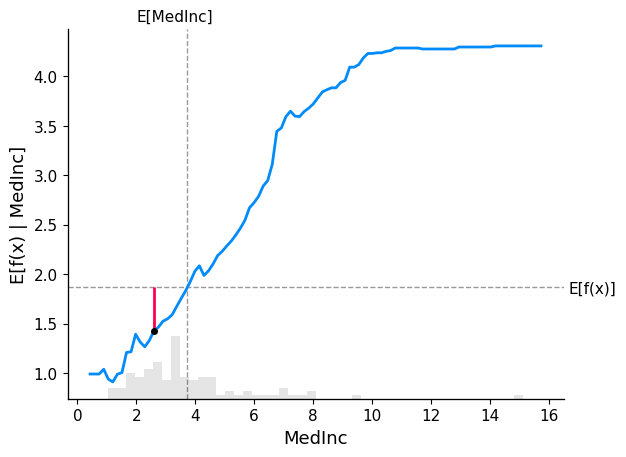

In [14]:
# explica el modelo GAM con SHAP
explainer_ebm = shap.Explainer(model_ebm.predict, X100)
shap_values_ebm = explainer_ebm(X)

# dependencia parcial
fig, ax = shap.partial_dependence_plot(
    "MedInc",
    model_ebm.predict,
    X100,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
    shap_values=shap_values_ebm[sample_ind : sample_ind + 1, :],
)

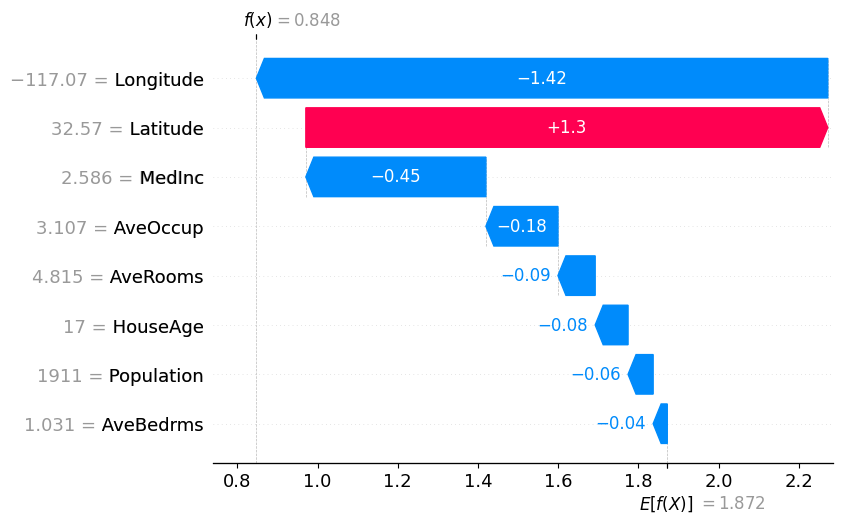

In [15]:
# the waterfall_plot shows how we get from explainer.expected_value to model.predict(X)[sample_ind]
shap.plots.waterfall(shap_values_ebm[sample_ind])

Para el conjunto total de muestras disponemos del `beeswarm`. Nos muestra las contribuciones por característica y muestra indicando en colores su pero y en el eje X su contribución al modelo final.

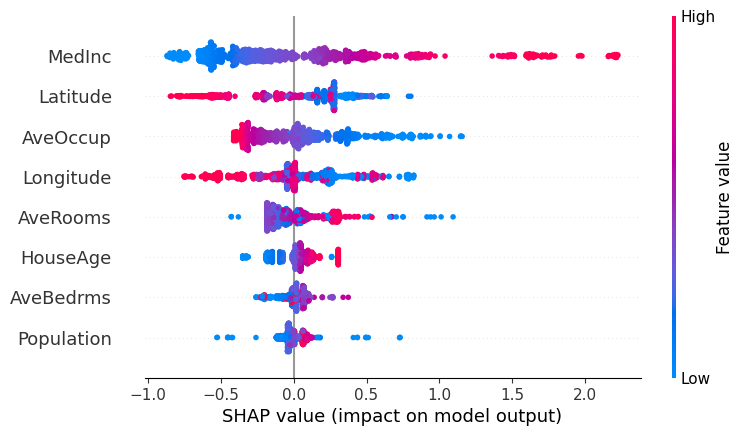

In [12]:
shap.plots.beeswarm(shap_values_ebm)

En última instancia podemos emplearlos para entender la contribución en modelos más difíciles de interpretar de por si.

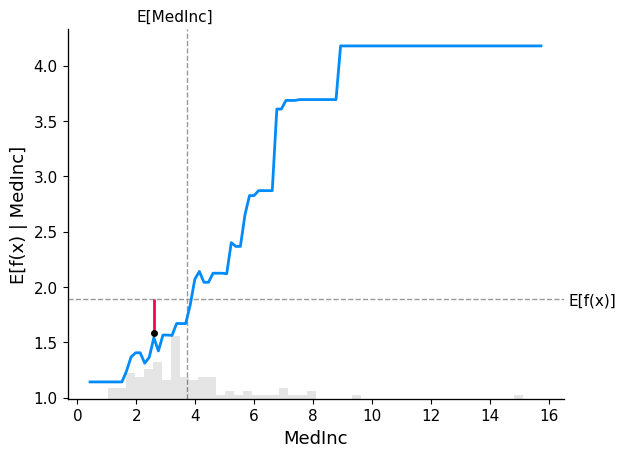

In [16]:
import xgboost

model_xgb = xgboost.XGBRegressor(n_estimators=100, max_depth=2).fit(X, y)

explainer_xgb = shap.Explainer(model_xgb, X100)
shap_values_xgb = explainer_xgb(X)

fig, ax = shap.partial_dependence_plot(
    "MedInc",
    model_xgb.predict,
    X100,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
    shap_values=shap_values_xgb[sample_ind : sample_ind + 1, :],
)

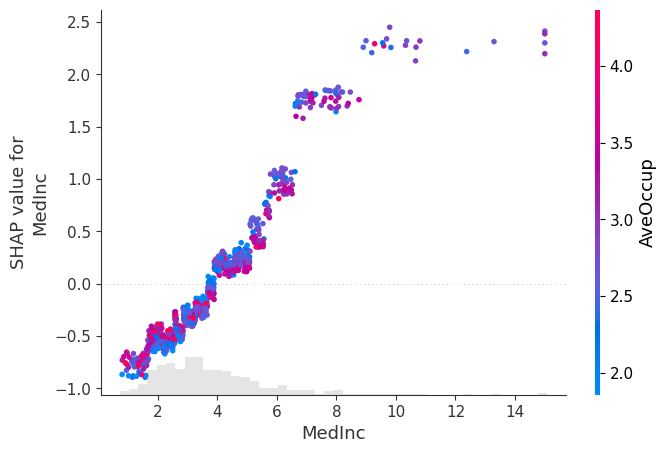

In [17]:
shap.plots.scatter(shap_values_xgb[:, "MedInc"], color=shap_values)

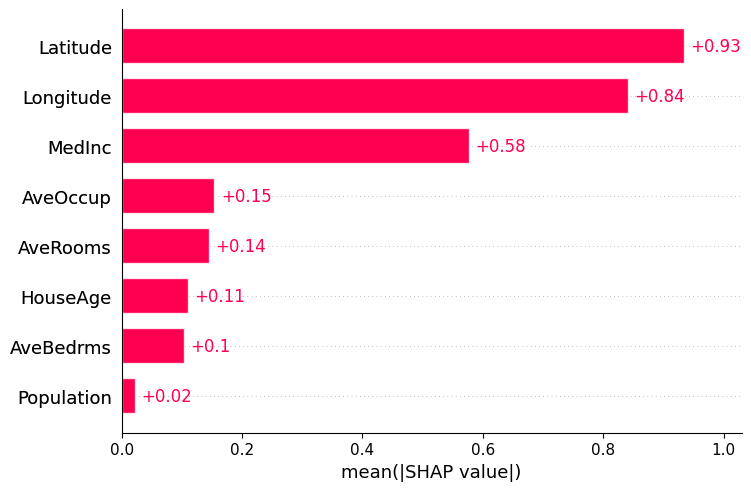

In [18]:
shap.plots.bar(shap_values)

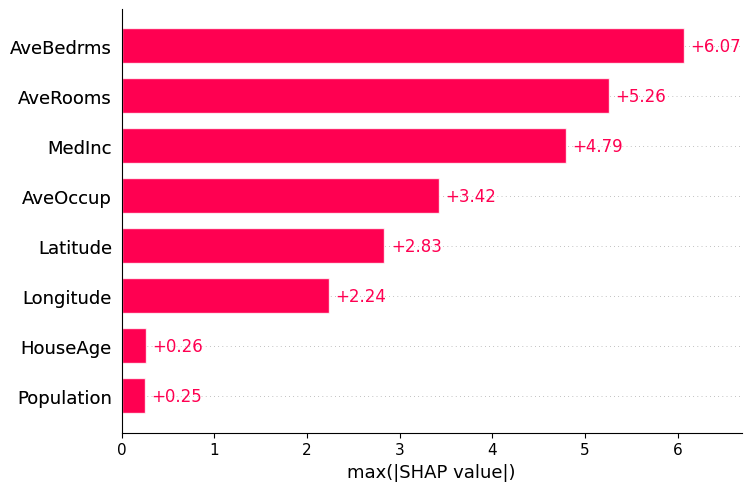

In [19]:
shap.plots.bar(shap_values.abs.max(0))

Incluso podemos usar estos valores para entender qué partes de una imagen influyeron en la decisión de una [red neuronal convolucional](https://shap.readthedocs.io/en/latest/example_notebooks/image_examples/image_classification/Explain%20ResNet50%20using%20the%20Partition%20explainer.html#Visualizing-SHAP-values-output).

Es importante porque esto nos ayuda a entender las decisiones de nuestro modelo. Dado un modelo que muestre las siguientes métricas

![perrolobo](img/perrolobo.png)

qué decís que diría ante un nuevo caso como este?

![corgi](img/corgi.png)

La respuesta la tenéis aquí: https://arxiv.org/pdf/1602.04938 

## Fairness

Poder evaluar lo justo que es nuestro modelo ante diferentes audiencias será clave en entornos regulados o con un especial interés en no generar desigualdades entre nuestros clientes. Para ello, disponemos de librerías que nos facilitan la tarea de evaluar estos aspectos.

In [22]:
# !pip install fairlearn

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fairlearn.datasets import fetch_adult

data = fetch_adult(as_frame=True)
data.data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States


In [24]:
X = pd.get_dummies(data.data)
y_true = (data.target == '>50K') * 1
sex = data.data['sex']
sex.value_counts()

sex
Male      32650
Female    16192
Name: count, dtype: int64

Vemos que hay un desbalance importante en nuestra base de datos. Supongamos que seguimos adelante sin prestar mucha atención a este aspecto.

In [25]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(min_samples_leaf=10, max_depth=4)
classifier.fit(X, y_true)

y_pred = classifier.predict(X)
accuracy_score(y_pred=y_pred, y_true=y_true)

0.8443552680070431

In [26]:
from fairlearn.metrics import MetricFrame

mf = MetricFrame(metrics=accuracy_score, y_true=y_true, y_pred=y_pred, sensitive_features=sex)
mf.overall

np.float64(0.8443552680070431)

In [27]:
mf.by_group

sex
Female    0.925148
Male      0.804288
Name: accuracy_score, dtype: float64

A priori parece que tenemos un buen clasificador incluso por clase. Pero si vemos por ejemplo, cual es nuestro rango de población con etiqueta positiva (1).

In [28]:
from fairlearn.metrics import selection_rate

sr = MetricFrame(metrics=selection_rate, y_true=y_true, y_pred=y_pred, sensitive_features=sex)
sr.overall

np.float64(0.16385487899758405)

In [29]:
sr.by_group

sex
Female    0.063550
Male      0.213599
Name: selection_rate, dtype: float64

Vemos que hay un ratio muy desfavorable hacia una de los grupos considerados. De hecho, podemos mostrar varias de estas métricas en conjunto para entender mejor la disparidad generada.

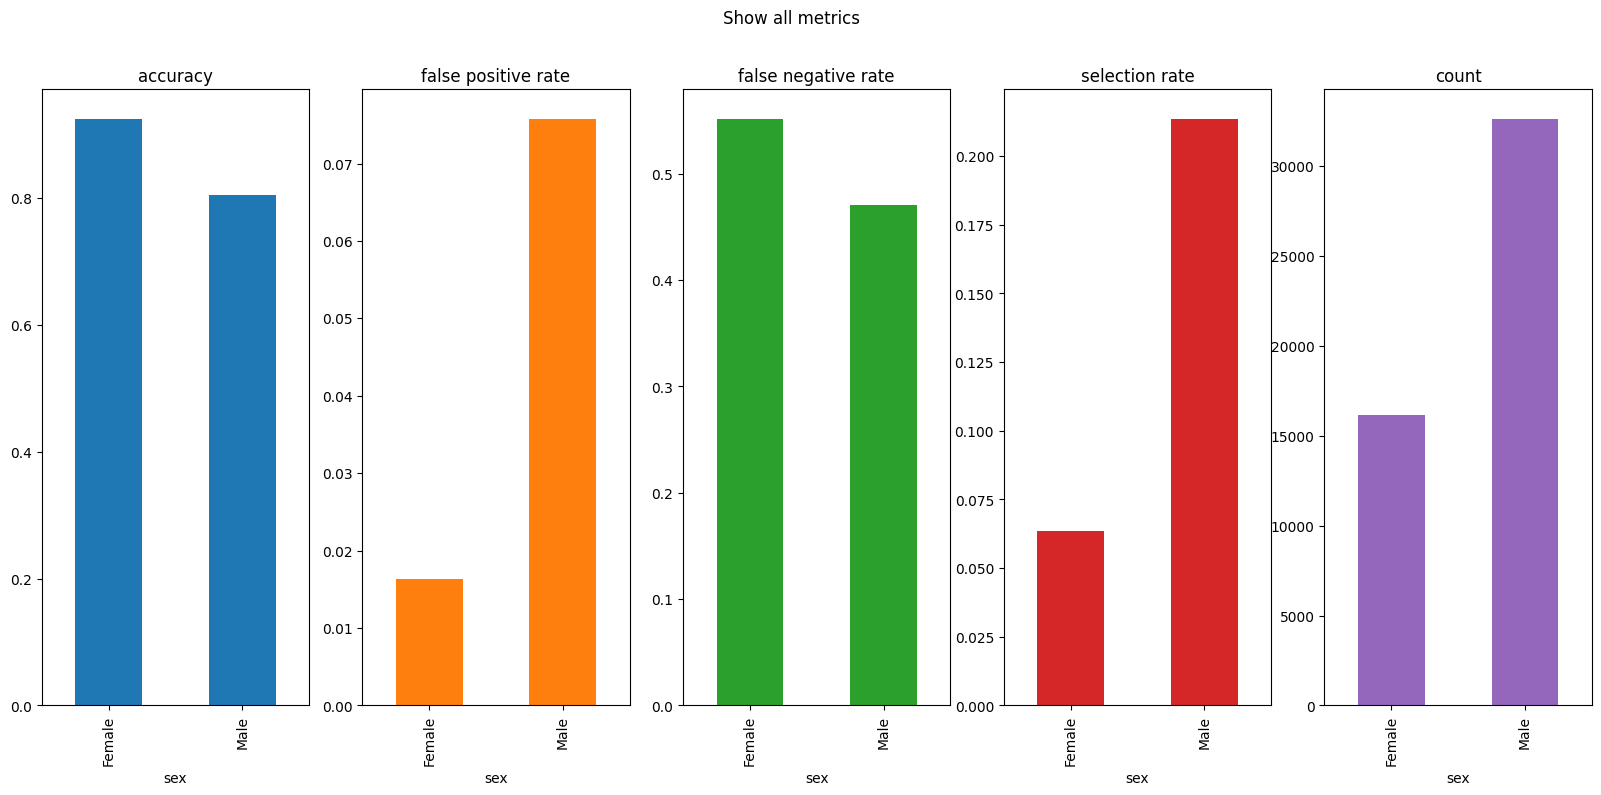

In [30]:
from fairlearn.metrics import *

metrics = {
    "accuracy": accuracy_score,
    "false positive rate": false_positive_rate,
    "false negative rate": false_negative_rate,
    "selection rate": selection_rate,
    "count": count,
}
metric_frame = MetricFrame(
    metrics=metrics, y_true=y_true, y_pred=y_pred, sensitive_features=sex
)
metric_frame.by_group.plot.bar(
    subplots=True,
    layout=[1, 5],
    legend=False,
    figsize=[20, 8],
    title="Show all metrics",
);


Fairlean permite realizar una mitigación de cara a disponer de un modelo más justo. Podemos emplear una métrica de [paridad demográfica](https://fairlearn.org/v0.12/user_guide/assessment/common_fairness_metrics.html#demographic-parity) que buscará que nuestro modelo se _insensible_ en sus predicciones a la pertenencia a un grupo dado.

In [31]:
import warnings
from fairlearn.reductions import DemographicParity, ExponentiatedGradient

warnings.filterwarnings(action="ignore")
np.random.seed(0)

constraint = DemographicParity()
mitigator = ExponentiatedGradient(classifier, constraint)
mitigator.fit(X, y_true, sensitive_features=sex)

ExponentiatedGradient(constraints=<fairlearn.reductions._moments.utility_parity.DemographicParity object at 0x7e062791ecf0>,
                      estimator=DecisionTreeClassifier(max_depth=4,
                                                       min_samples_leaf=10),
                      nu=np.float64(0.0008201769357601916))

In [32]:
y_pred_mitigated = mitigator.predict(X)

sr_mitigated = MetricFrame(metrics=selection_rate, y_true=y_true, y_pred=y_pred_mitigated, sensitive_features=sex)
sr_mitigated.overall

np.float64(0.16614798738790384)

In [33]:
sr_mitigated.by_group

sex
Female    0.155262
Male      0.171547
Name: selection_rate, dtype: float64

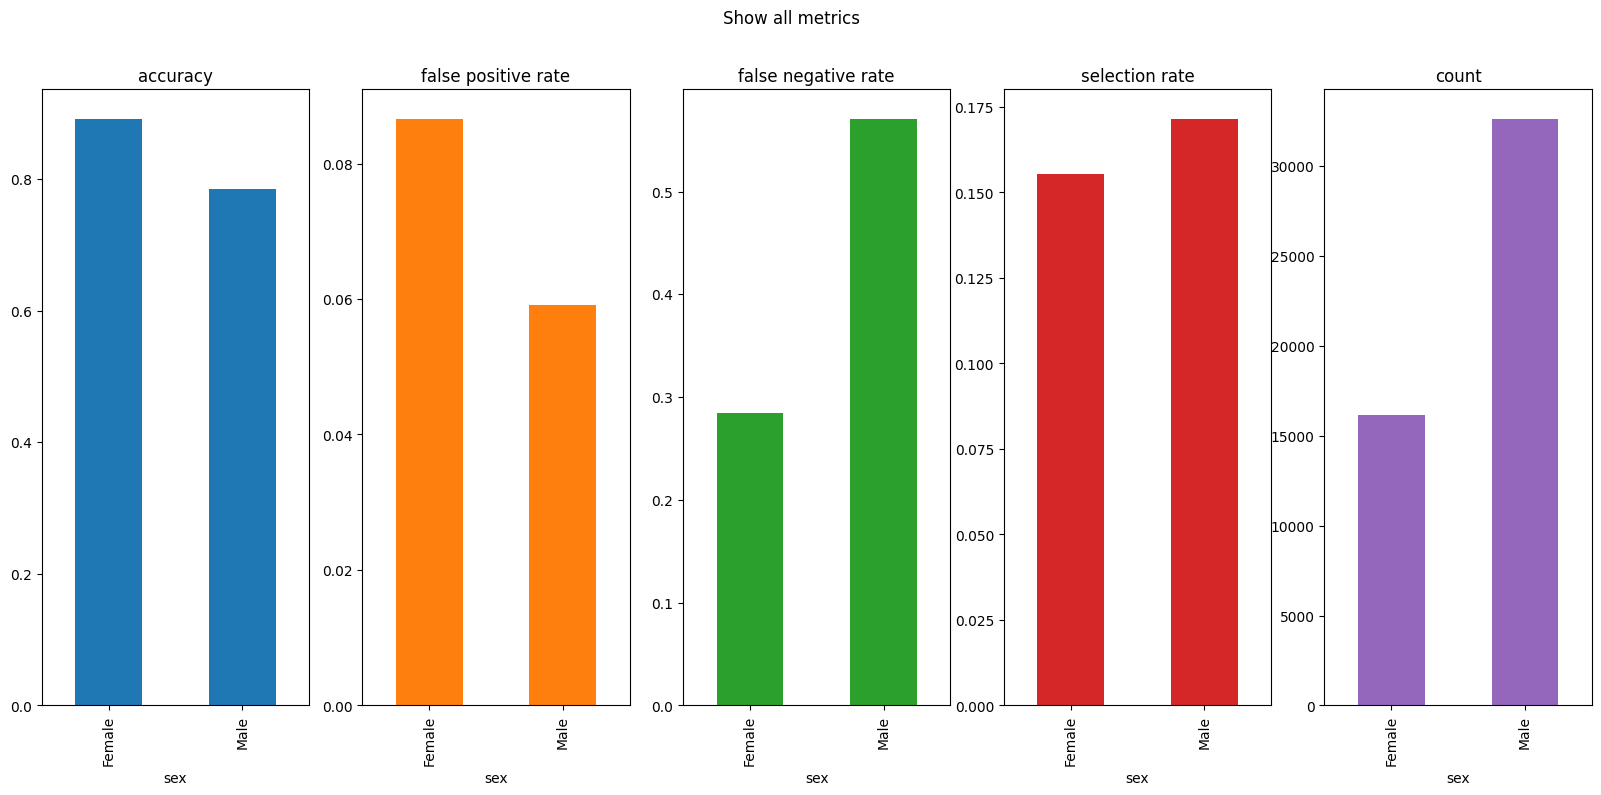

In [34]:
metrics = {
    "accuracy": accuracy_score,
    "false positive rate": false_positive_rate,
    "false negative rate": false_negative_rate,
    "selection rate": selection_rate,
    "count": count,
}
metric_frame = MetricFrame(
    metrics=metrics, y_true=y_true, y_pred=y_pred_mitigated, sensitive_features=sex
)
metric_frame.by_group.plot.bar(
    subplots=True,
    layout=[1, 5],
    legend=False,
    figsize=[20, 8],
    title="Show all metrics",
);


In [64]:
from fairlearn.datasets import fetch_adult

data = fetch_adult()
X = data["data"]
y = data['target']

In [65]:
X.describe(include='all')

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
count,48842.000000,46043,4.884200e+04,48842,48842.000000,48842,46033,48842,48842,48842,48842.000000,48842.000000,48842.000000,47985
unique,NaN,8,NaN,16,NaN,7,14,6,5,2,NaN,NaN,NaN,41
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN


In [66]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
dtypes: category(8), int64(6)
memory usage: 2.6 MB


In [67]:
y.value_counts(normalize=True)

class
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64

Tenemos cierto desbalance en nuestras muestras, esto podremos necesitar compensarlo o al menos indicar a los modelos que lo balanceen si disponen de esa opción.

Trabajamos con el conjunto de datos y simplificamos algunas opciones:

In [68]:
def raza_simplificada(input_str):
    """White, Black u Other."""
    result = 'Other'
    if input_str == 'White' or input_str == 'Black':
        result = input_str
    return result

X['race'] = X['race'].map(raza_simplificada).fillna('Other')
X['race'].unique()

array(['Black', 'White', 'Other'], dtype=object)

In [69]:
def estado_marital(m_s_string):
    result = 'Low'
    if m_s_string.startswith("Married"):
        result = 'Medium'
    elif m_s_string.startswith("Widowed"):
        result = 'High'
    return result

col_credit = X['marital-status'].map(estado_marital).fillna('Low')
col_credit.name = "punt_credit"

In [70]:
def oficio(occ_string):
    result = 'Small'
    if occ_string.startswith("Machine"):
        result = 'Large'
    return result

col_loan_size = X['occupation'].astype(str).map(oficio).fillna('Small')
col_loan_size.name = "prestamo"

In [72]:
X_subset = X[['race', 'sex']]
X_subset['punt_credit'] = col_credit
X_subset['prestamo'] = col_loan_size
X_subset

,race,sex,punt_credit,prestamo
0,Black,Male,Low,Large
1,White,Male,Medium,Small
2,White,Male,Medium,Small
3,Black,Male,Medium,Large
4,White,Female,Low,Small
...,...,...,...,...
48837,White,Female,Medium,Small
48838,White,Male,Medium,Large
48839,White,Female,High,Small
48840,White,Male,Low,Small


In [75]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

sc = StandardScaler()
X_dummies = pd.get_dummies(X)
X_scaled = sc.fit_transform(X_dummies)
X_scaled = pd.DataFrame(X_scaled, columns=X_dummies.columns)

le = LabelEncoder()
y_cod = le.fit_transform(y)

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test, S_train, S_test = train_test_split(X_scaled, y_cod, X_subset,
                                                                     test_size=0.3,
                                                                     random_state=12345,
                                                                     stratify=y_cod)


X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
S_train = S_train.reset_index(drop=True)
S_test = S_test.reset_index(drop=True)

In [81]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(solver='liblinear', fit_intercept=True, class_weight='balanced')
modelo.fit(X_train, Y_train)

modelo.score(X_test, Y_test)

0.805432334675493

In [83]:
from sklearn.metrics import classification_report

Y_pred = modelo.predict(X_test)
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.94      0.79      0.86     11147
           1       0.56      0.85      0.68      3506

    accuracy                           0.81     14653
   macro avg       0.75      0.82      0.77     14653
weighted avg       0.85      0.81      0.82     14653



Calculamos los ratios de selección (candidatos que pueden optar a un préstamo de más de 50k$) y el $F_{\beta}$ score (generalización del $F_1$).

In [79]:
import sklearn.metrics as skm

print("Selection Rate:", selection_rate(Y_test, Y_pred))
print("fbeta:", skm.fbeta_score(Y_test, Y_pred, beta=0.6))

Selection Rate: 0.36176892104006003
fbeta: 0.6170929856959148


¿Y si lo miramos por grupos poblacionales?

In [99]:
import functools

fbeta_06 = functools.partial(skm.fbeta_score, beta=0.6)
metric_fns = {'selection_rate': selection_rate, 'fbeta_06': fbeta_06}
grouped_on_sex = MetricFrame(metrics=metric_fns,
                             y_true=Y_test,
                             y_pred=Y_pred,
                             sensitive_features=S_test['sex'])

grouped_on_sex.by_group

,selection_rate,fbeta_06
sex,,
Female,0.135548,0.578710
Male,0.473588,0.622737


In [100]:
grouped_on_sex.difference(method='between_groups')


selection_rate    0.338040
fbeta_06          0.044027
dtype: float64

In [101]:
grouped_on_race = MetricFrame(metrics=metric_fns,
                             y_true=Y_test,
                             y_pred=Y_pred,
                             sensitive_features=S_test['race'])

grouped_on_race.by_group

,selection_rate,fbeta_06
race,,
Black,0.158774,0.600222
Other,0.314607,0.597856
White,0.387765,0.618800


In [102]:
grouped_on_race.difference(method='between_groups')


selection_rate    0.228991
fbeta_06          0.020945
dtype: float64

Veamos como resultan estas agregaciones en base a uno de los criterios que afectan directamente la variable objetivo. Es normal que exista un mayor ratio de selección cuando la puntuación crediticia es alta y menor cuando es baja, pero no debería mostrar grandes desvíos en base a criterios como raza o sexo.

In [95]:
cond_credit_score = MetricFrame(metrics=metric_fns,
                                y_true=Y_test,
                                y_pred=Y_pred,
                                sensitive_features=S_test[['race', 'sex']],
                                control_features=S_test['punt_credit'])

In [96]:
cond_credit_score.overall

,selection_rate,fbeta_06
punt_credit,,
High,0.069264,0.581694
Low,0.052668,0.476709
Medium,0.695578,0.629596


In [97]:
cond_credit_score.by_group

selection_rate  fbeta_06
punt_credit race  sex                             
High        Black Female        0.000000  0.000000
                  Male          0.200000  1.000000
            Other Female        0.000000  0.000000
                  Male          0.000000  0.000000
            White Female        0.042071  0.434968
                  Male          0.227848  0.691706
Low         Black Female        0.007055  0.341709
                  Male          0.033248  0.392610
            Other Female        0.005882  0.000000
                  Male          0.067416  0.374656
            White Female        0.034314  0.473124
                  Male          0.083111  0.495424
Medium      Black Female        0.384615  0.523501
                  Male          0.532915  0.643330
            Other Female        0.462687  0.539112
                  Male          0.647482  0.633692
            White Female        0.663842  0.625087
                  Male          0.719993  0.631116

¿Se os ocurre como ajustar mejor este modelo? Sería cuestión de buscar si podemos mitigar las predicciones como hemos visto antes.

In [ ]:
# Vuestro código